In [2]:
from google.colab import files
from google.colab import drive
import shutil
import os
import pandas as pd

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Set up the specific directory
drive_folder = '/content/drive/MyDrive/Statsbomb_Data/'
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)
    print(f"Created folder: {drive_folder}")

# 3. Open the file picker for the cleaned dataset
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

    # Destination name specifically for the encoded data
    destination = os.path.join(drive_folder, 'shots_final.csv')

    # Move the file to Drive
    shutil.move(filename, destination)
    print(f"✅ Success! Moved {filename} to {destination}")

# 4. Load it into your DataFrame
df = pd.read_csv(destination)
print(f"✅ DataFrame loaded with {len(df)} rows and {len(df.columns)} columns.")

Mounted at /content/drive


Saving shots_final.csv to shots_final.csv
User uploaded file "shots_final.csv" with length 12371516 bytes
✅ Success! Moved shots_final.csv to /content/drive/MyDrive/Statsbomb_Data/shots_final.csv
✅ DataFrame loaded with 64898 rows and 41 columns.


In [3]:
df.columns

Index(['x', 'y', 'distance', 'angle', 'angle_deviation', 'is_goal',
       'shot_first_time', 'under_pressure', 'shot_one_on_one',
       'shot_deflected', 'shot_open_goal', 'shot_redirect',
       'shot_follows_dribble', 'shot_aerial_won', 'period', 'minute',
       'shot_statsbomb_xg', 'player', 'team', 'competition_name',
       'season_name', 'body_Head', 'body_Left Foot', 'body_Other',
       'body_Right Foot', 'tech_Backheel', 'tech_Diving Header',
       'tech_Half Volley', 'tech_Lob', 'tech_Normal', 'tech_Overhead Kick',
       'tech_Volley', 'pattern_From Corner', 'pattern_From Counter',
       'pattern_From Free Kick', 'pattern_From Goal Kick',
       'pattern_From Keeper', 'pattern_From Kick Off', 'pattern_From Throw In',
       'pattern_Other', 'pattern_Regular Play'],
      dtype='object')

In [4]:
df.head()

,x,y,distance,angle,angle_deviation,is_goal,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,...,tech_Volley,pattern_From Corner,pattern_From Counter,pattern_From Free Kick,pattern_From Goal Kick,pattern_From Keeper,pattern_From Kick Off,pattern_From Throw In,pattern_Other,pattern_Regular Play
0,100.4,35.1,20.203218,75.963757,14.036243,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,114.6,33.5,8.450444,39.718759,50.281241,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,106.2,55.8,20.978084,138.865461,48.865461,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,113.9,47.4,9.590099,140.500411,50.500411,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,89.2,42.5,30.901294,94.640458,4.640458,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
spatial_features = ['distance', 'angle', 'angle_deviation']
situational_features = [
    'shot_first_time', 'under_pressure', 'shot_one_on_one',
    'shot_deflected', 'shot_open_goal', 'shot_redirect',
    'shot_follows_dribble', 'shot_aerial_won'
]
body_features = ['body_Head', 'body_Left Foot', 'body_Right Foot']
tech_features = ['tech_Normal', 'tech_Volley', 'tech_Half Volley', 'tech_Lob']
pattern_features = [
    'pattern_Regular Play', 'pattern_From Counter',
    'pattern_From Corner', 'pattern_From Free Kick', 'pattern_From Throw In'
]

final_features = spatial_features + situational_features + body_features + tech_features + pattern_features

# Check if all features exist in the dataframe
missing_features = [f for f in final_features if f not in df.columns]
print(f"\nMissing features: {missing_features}")
print(f"Total features to be used: {len(final_features)}")

# Previewing X and y
X = df[final_features]
y = df['is_goal']
print("\nFeature matrix (X) shape:", X.shape)
print("Target vector (y) value counts:\n", y.value_counts())


Missing features: []
Total features to be used: 23

Feature matrix (X) shape: (64898, 23)
Target vector (y) value counts:
 is_goal
0    57754
1     7144
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"✅ Data Split Successful!")
print(f"Training set size: {X_train.shape[0]} shots")
print(f"Testing set size: {X_test.shape[0]} shots")
print(f"\nGoal ratio in Training: {y_train.mean():.2%}")
print(f"Goal ratio in Testing: {y_test.mean():.2%}")

✅ Data Split Successful!
Training set size: 51918 shots
Testing set size: 12980 shots

Goal ratio in Training: 11.01%
Goal ratio in Testing: 11.01%


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import xgboost as xgb

In [9]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
y_pred_proba_lr = lr_model.predict_proba(X_test)[:,1]
y_pred_proba_lr[:10]

array([0.06808413, 0.0217501 , 0.06182315, 0.02277624, 0.15311775,
       0.22903112, 0.1386953 , 0.0021677 , 0.02529116, 0.07761376])

In [14]:
# 1. Calculate the metrics
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
logloss_lr = log_loss(y_test, y_pred_proba_lr)
brier_lr = brier_score_loss(y_test, y_pred_proba_lr)

# 2. Print results
print("--- 📋 Logistic Regression Evaluation ---")
print(f"ROC-AUC Score: {auc_lr:.4f}")
print(f"Log Loss:      {logloss_lr:.4f}")
print(f"Brier Score:   {brier_lr:.4f}")

--- 📋 Logistic Regression Evaluation ---
ROC-AUC Score: 0.8063
Log Loss:      0.2748
Brier Score:   0.0785


In [15]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_proba_xgb[:10]

array([0.06578118, 0.02302544, 0.03862412, 0.02887923, 0.19466785,
       0.17519513, 0.09065089, 0.00744806, 0.03306865, 0.10094382],
      dtype=float32)

In [17]:
# 1. Calculate the metrics
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
logloss_xgb = log_loss(y_test, y_pred_proba_xgb)
brier_xgb = brier_score_loss(y_test, y_pred_proba_xgb)

# 2. Print results
print("--- 📋 XGB Model Evaluation ---")
print(f"ROC-AUC Score: {auc_xgb:.4f}")
print(f"Log Loss:      {logloss_xgb:.4f}")
print(f"Brier Score:   {brier_xgb:.4f}")

--- 📋 XGB Model Evaluation ---
ROC-AUC Score: 0.8131
Log Loss:      0.2702
Brier Score:   0.0773


In [19]:
df['xG_xgb'] = xgb_model.predict_proba(X)[:,1]
comparison_preview = df[['x', 'y', 'distance', 'angle', 'angle_deviation', 'is_goal', 'shot_statsbomb_xg', 'xG_xgb']]
comparison_preview.head(25)

,x,y,distance,angle,angle_deviation,is_goal,shot_statsbomb_xg,xG_xgb
0,100.4,35.1,20.203218,75.963757,14.036243,0,0.056644,0.068475
1,114.6,33.5,8.450444,39.718759,50.281241,0,0.143381,0.247810
2,106.2,55.8,20.978084,138.865461,48.865461,0,0.038188,0.038191
3,113.9,47.4,9.590099,140.500411,50.500411,0,0.052781,0.066192
4,89.2,42.5,30.901294,94.640458,4.640458,0,0.021272,0.014395
5,110.2,32.6,12.280065,52.943472,37.056528,0,0.029664,0.032267
6,105.4,45.1,15.465122,109.255078,19.255078,0,0.082293,0.147484
7,108.0,40.0,12.000000,90.000000,0.000000,1,0.783500,0.722193
8,101.5,47.5,19.962465,112.067900,22.067900,0,0.050110,0.038169
9,116.3,46.0,7.049113,148.339249,58.339249,0,0.109917,0.062930


In [21]:
df['xG_lr'] = lr_model.predict_proba(X)[:,1]
comparison_preview = df[['x', 'y', 'distance', 'angle', 'angle_deviation', 'is_goal', 'shot_statsbomb_xg', 'xG_xgb', 'xG_lr']]
comparison_preview.head(50)

,x,y,distance,angle,angle_deviation,is_goal,shot_statsbomb_xg,xG_xgb,xG_lr
0,100.4,35.1,20.203218,75.963757,14.036243,0,0.056644,0.068475,0.088690
1,114.6,33.5,8.450444,39.718759,50.281241,0,0.143381,0.247810,0.239625
2,106.2,55.8,20.978084,138.865461,48.865461,0,0.038188,0.038191,0.039403
3,113.9,47.4,9.590099,140.500411,50.500411,0,0.052781,0.066192,0.060837
4,89.2,42.5,30.901294,94.640458,4.640458,0,0.021272,0.014395,0.013291
5,110.2,32.6,12.280065,52.943472,37.056528,0,0.029664,0.032267,0.025529
6,105.4,45.1,15.465122,109.255078,19.255078,0,0.082293,0.147484,0.153927
7,108.0,40.0,12.000000,90.000000,0.000000,1,0.783500,0.722193,0.518985
8,101.5,47.5,19.962465,112.067900,22.067900,0,0.050110,0.038169,0.051000
9,116.3,46.0,7.049113,148.339249,58.339249,0,0.109917,0.062930,0.042332


In [22]:
from sklearn.metrics import mean_absolute_error

# 1. Calculate Correlation
correlation_xgb = df['xG_xgb'].corr(df['shot_statsbomb_xg'])

# 2. Calculate Mean Absolute Error (MAE)
mae_xgb = mean_absolute_error(df['shot_statsbomb_xg'], df['xG_xgb'])

In [23]:
print(f"--- My xG Model vs StatsBomb Statistics ---")
print(f"Correlation: {correlation_xgb:.4f}")
print(f"Mean Absolute Error: {mae_xgb:.4f}")

--- My xG Model vs StatsBomb Statistics ---
Correlation: 0.8663
Mean Absolute Error: 0.0395


In [24]:
# 1. Calculate Correlation
correlation_lr = df['xG_lr'].corr(df['shot_statsbomb_xg'])

# 2. Calculate Mean Absolute Error (MAE)
mae_lr = mean_absolute_error(df['shot_statsbomb_xg'], df['xG_lr'])

print(f"--- My xG Model 2 vs StatsBomb Statistics ---")
print(f"Correlation: {correlation_lr:.4f}")
print(f"Mean Absolute Error: {mae_lr:.4f}")

--- My xG Model 2 vs StatsBomb Statistics ---
Correlation: 0.8290
Mean Absolute Error: 0.0460


In [25]:
import pickle

# 1. Save the updated dataset (now containing statscout_xg)
df.to_csv('XG_final_dataset.csv', index=False)
print("✅ Dataset saved: 'XG_final_dataset.csv'")

# 2. Save the XGBoost Model (The Winner)
with open('XG_xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("✅ XGBoost model saved: 'XG_xgb_model.pkl'")

# 3. Save the Logistic Regression Model (The Baseline)
with open('XG_lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Logistic Regression model saved: 'XG_lr_model.pkl'")

✅ Dataset saved: 'XG_final_dataset.csv'
✅ XGBoost model saved: 'XG_xgb_model.pkl'
✅ Logistic Regression model saved: 'XG_lr_model.pkl'


In [27]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.7 MB/s eta 0:00:00


In [41]:
from mplsoccer import Pitch
pitch = Pitch(pitch_type='statsbomb')

In [34]:
df = df.sort_values(by='xG_xgb', ascending=True)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap



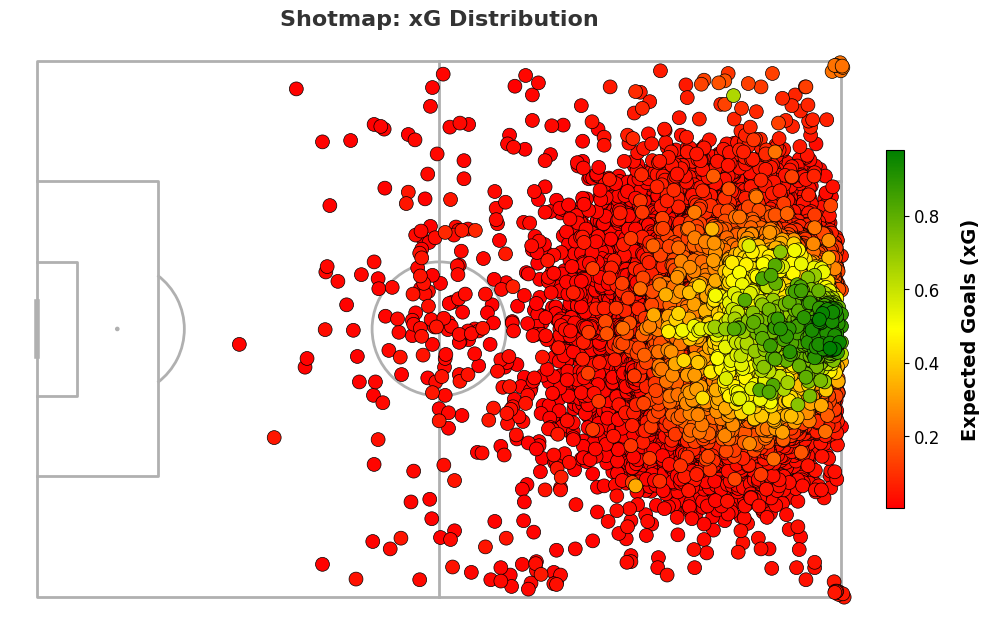

In [50]:
colors = ['red', 'yellow', 'green']
cmap = LinearSegmentedColormap.from_list('my_colormap', colors)
fig, ax = pitch.draw(figsize=(10,8))
sc = pitch.scatter(
    df['x'],
    df['y'],
    c = df['xG_xgb'],
    cmap=cmap,
    #s=df['xG_xgb'] * 500,
    s=100,
    edgecolors='black',
    #alpha=0.6,
    linewidth=.5,
    ax=ax
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.02, pad=.02)
cbar.set_label('Expected Goals (xG)', size=14, weight='bold', labelpad=15)
cbar.ax.tick_params(labelsize=12)
ax.set_title('Shotmap: xG Distribution',
             fontsize=16,
             fontweight='bold',
             color='#333333',
             loc='center')
plt.show()